In [15]:
import pandas as pd
import requests

url = "https://api.neso.energy/api/3/action/datastore_search"
params = {
    "resource_id": "8a4a771c-3929-4e56-93ad-cdf13219dea5",  # Historic Demand Data 2026
    "limit": 5
}
resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
resp.json()

200


{'help': 'https://api.neso.energy/api/3/action/help_show?name=datastore_search',
 'success': True,
 'result': {'include_total': True,
  'resource_id': '8a4a771c-3929-4e56-93ad-cdf13219dea5',
  'fields': [{'type': 'int', 'id': '_id'},
   {'info': {'comment': 'This follows clock change.',
     'description': 'The date the historic outturn occurred.',
     'title': 'Settlement Date',
     'type': 'date',
     'example': '01/01/2026',
     'unit': ''},
    'type': 'date',
    'id': 'SETTLEMENT_DATE'},
   {'info': {'comment': '',
     'description': 'The half hourly period for the historic outturn occurred. Settlement period 1 runs from 00:00-00:30.',
     'title': 'Settlement Period',
     'type': 'integer',
     'example': '1',
     'unit': ''},
    'type': 'int4',
    'id': 'SETTLEMENT_PERIOD'},
   {'info': {'comment': '',
     'description': 'This is the Great Britain generation requirement and is equivalent to the Initial National Demand Outturn (INDO) and National Demand Forecast as p

In [16]:
# Pull all available records for 2026
params = {
    "resource_id": "8a4a771c-3929-4e56-93ad-cdf13219dea5",
    "limit": 12000  # more than the ~11,950 total, so we get everything in one call
}
resp = requests.get(url, params=params, timeout=60)
data = resp.json()
print(data["result"]["total"], "total records")

df = pd.DataFrame(data["result"]["records"])
print(df.shape)
df.head()

11950 total records
(11950, 24)


,_id,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,FORECAST_ACTUAL_INDICATOR,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,1,2026-01-01,1,25107,A,29668,23625,4146,6417,0,...,-1143,-610,989,-361,-527,209,677,-352,1021,-513
1,2,2026-01-01,2,25881,A,30361,24341,4188,6417,0,...,-1132,-606,1005,-361,-453,243,648,-359,994,-514
2,3,2026-01-01,3,25355,A,30681,23805,4085,6417,0,...,-1433,-594,844,-361,-524,343,667,-754,994,-514
3,4,2026-01-01,4,24762,A,30225,23226,4092,6417,0,...,-1469,-589,837,-361,-531,346,650,-770,990,-514
4,5,2026-01-01,5,24111,A,29092,22653,4044,6417,0,...,-1236,-431,949,-361,-531,146,413,-475,990,-513


In [17]:
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"])
# each settlement period is 30 minutes, period 1 = 00:00
df["timestamp"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
df = df.sort_values("timestamp").reset_index(drop=True)
df[["timestamp", "ND"]].head()

,timestamp,ND
0,2026-01-01 00:00:00,25107
1,2026-01-01 00:30:00,25881
2,2026-01-01 01:00:00,25355
3,2026-01-01 01:30:00,24762
4,2026-01-01 02:00:00,24111


In [18]:
# 1. Are there any non-actual rows mixed in?
print(df["FORECAST_ACTUAL_INDICATOR"].value_counts())

# 2. Expected vs actual row count (48 half-hour periods per day)
expected_periods = df["timestamp"].dt.date.nunique() * 48
print("expected:", expected_periods, "| actual:", len(df))

# 3. Any duplicate timestamps?
print("duplicates:", df["timestamp"].duplicated().sum())

# 4. Any gaps in the time index?
full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="30min")
missing = full_range.difference(df["timestamp"])
print("missing timestamps:", len(missing))
if len(missing) > 0:
    print(missing[:10])

FORECAST_ACTUAL_INDICATOR
A    11950
Name: count, dtype: int64
expected: 11952 | actual: 11950
duplicates: 0
missing timestamps: 2
DatetimeIndex(['2026-03-29 23:00:00', '2026-03-29 23:30:00'], dtype='datetime64[ns]', freq='30min')


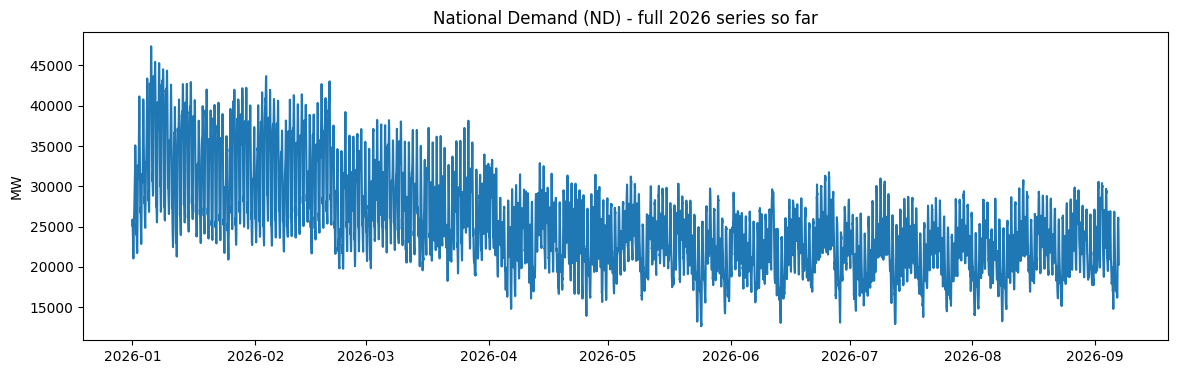

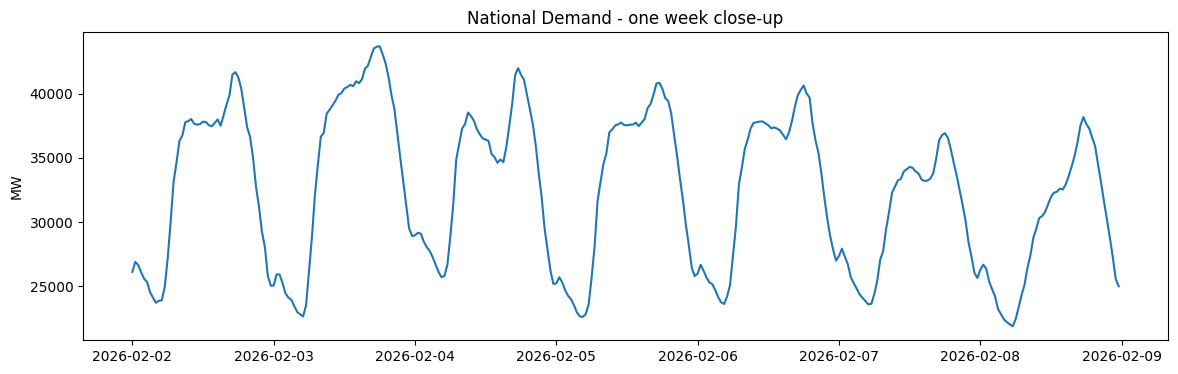

In [19]:
import matplotlib.pyplot as plt

# Full series
plt.figure(figsize=(14,4))
plt.plot(df["timestamp"], df["ND"])
plt.title("National Demand (ND) - full 2026 series so far")
plt.ylabel("MW")
plt.show()

# One week close-up, to see daily/weekly shape
one_week = df[(df["timestamp"] >= "2026-02-02") & (df["timestamp"] < "2026-02-09")]
plt.figure(figsize=(14,4))
plt.plot(one_week["timestamp"], one_week["ND"])
plt.title("National Demand - one week close-up")
plt.ylabel("MW")
plt.show()

In [20]:
cutoff = df["timestamp"].max() - pd.Timedelta(days=14)
train = df[df["timestamp"] <= cutoff].copy()
test = df[df["timestamp"] > cutoff].copy()
print(train.shape, test.shape)

# Naive seasonal baseline: value from exactly 7 days earlier
df_indexed = df.set_index("timestamp")["ND"]
test["naive_pred"] = (test["timestamp"] - pd.Timedelta(days=7)).map(df_indexed)

test[["timestamp", "ND", "naive_pred"]].head(10)

(11278, 25) (672, 25)


,timestamp,ND,naive_pred
11278,2026-08-24 00:00:00,21102,21833
11279,2026-08-24 00:30:00,20978,21653
11280,2026-08-24 01:00:00,20784,21366
11281,2026-08-24 01:30:00,20437,21338
11282,2026-08-24 02:00:00,20253,21208
11283,2026-08-24 02:30:00,19679,21061
11284,2026-08-24 03:00:00,19336,20765
11285,2026-08-24 03:30:00,19054,20210
11286,2026-08-24 04:00:00,18476,19862
11287,2026-08-24 04:30:00,18300,19648


In [21]:
import numpy as np

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

baseline_mae = mae(test["ND"], test["naive_pred"])
baseline_mape = mape(test["ND"], test["naive_pred"])
print(f"Naive baseline — MAE: {baseline_mae:.0f} MW, MAPE: {baseline_mape:.2f}%")

Naive baseline — MAE: 1755 MW, MAPE: 8.08%


hour
0      751.928571
1      885.464286
2      956.571429
3      668.571429
4      587.214286
5      609.357143
6      758.714286
7     1168.571429
8     1841.357143
9     2719.321429
10    3220.785714
11    3486.428571
12    3653.357143
13    3785.964286
14    3770.785714
15    3434.071429
16    2865.928571
17    2021.571429
18    1263.928571
19     737.035714
20     707.642857
21     652.571429
22     769.892857
23     792.964286
Name: abs_error, dtype: float64


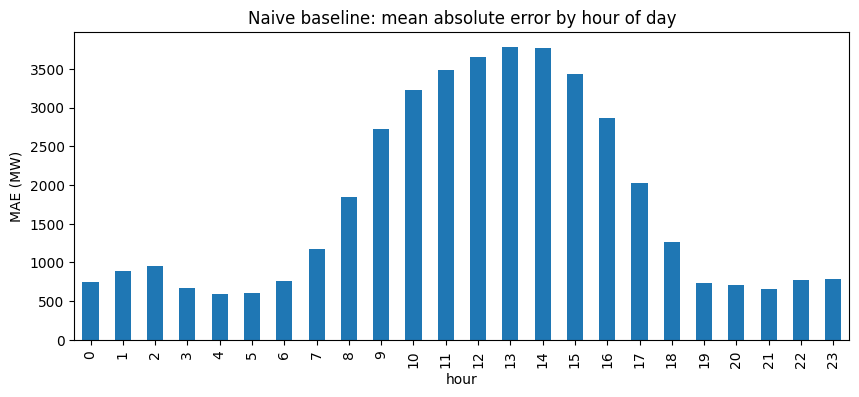

In [22]:
test["hour"] = test["timestamp"].dt.hour
test["abs_error"] = np.abs(test["ND"] - test["naive_pred"])

hourly_error = test.groupby("hour")["abs_error"].mean()
print(hourly_error)

plt.figure(figsize=(10,4))
hourly_error.plot(kind="bar")
plt.title("Naive baseline: mean absolute error by hour of day")
plt.ylabel("MAE (MW)")
plt.show()

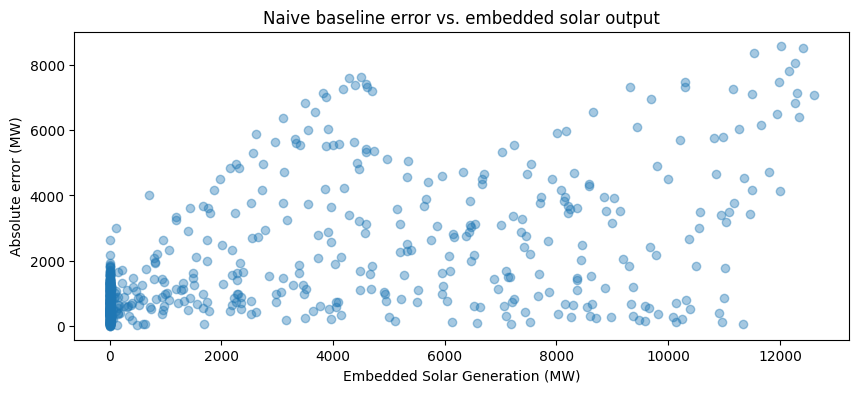

                           EMBEDDED_SOLAR_GENERATION  abs_error
EMBEDDED_SOLAR_GENERATION                   1.000000   0.570921
abs_error                                   0.570921   1.000000


In [23]:
test["abs_error"] = np.abs(test["ND"] - test["naive_pred"])

# Does higher/more variable embedded solar line up with bigger error?
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(test["EMBEDDED_SOLAR_GENERATION"], test["abs_error"], alpha=0.4)
plt.xlabel("Embedded Solar Generation (MW)")
plt.ylabel("Absolute error (MW)")
plt.title("Naive baseline error vs. embedded solar output")
plt.show()

print(test[["EMBEDDED_SOLAR_GENERATION", "abs_error"]].corr())

In [24]:
!pip install -q prophet

from prophet import Prophet

prophet_train = train[["timestamp", "ND"]].rename(columns={"timestamp": "ds", "ND": "y"})

m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
m.fit(prophet_train)

future = test[["timestamp"]].rename(columns={"timestamp": "ds"})
forecast = m.predict(future)

test["prophet_pred"] = forecast["yhat"].values
test[["timestamp", "ND", "naive_pred", "prophet_pred"]].head(10)

,timestamp,ND,naive_pred,prophet_pred
11278,2026-08-24 00:00:00,21102,21833,17638.610735
11279,2026-08-24 00:30:00,20978,21653,17393.227997
11280,2026-08-24 01:00:00,20784,21366,17150.832452
11281,2026-08-24 01:30:00,20437,21338,16836.068653
11282,2026-08-24 02:00:00,20253,21208,16415.251282
11283,2026-08-24 02:30:00,19679,21061,15907.982160
11284,2026-08-24 03:00:00,19336,20765,15384.428692
11285,2026-08-24 03:30:00,19054,20210,14948.924566
11286,2026-08-24 04:00:00,18476,19862,14714.014347
11287,2026-08-24 04:30:00,18300,19648,14771.463766


In [25]:
prophet_mae = mae(test["ND"], test["prophet_pred"])
prophet_mape = mape(test["ND"], test["prophet_pred"])
print(f"Prophet — MAE: {prophet_mae:.0f} MW, MAPE: {prophet_mape:.2f}%")
print(f"Naive   — MAE: {baseline_mae:.0f} MW, MAPE: {baseline_mape:.2f}%")

Prophet — MAE: 33837 MW, MAPE: 155.04%
Naive   — MAE: 1755 MW, MAPE: 8.08%


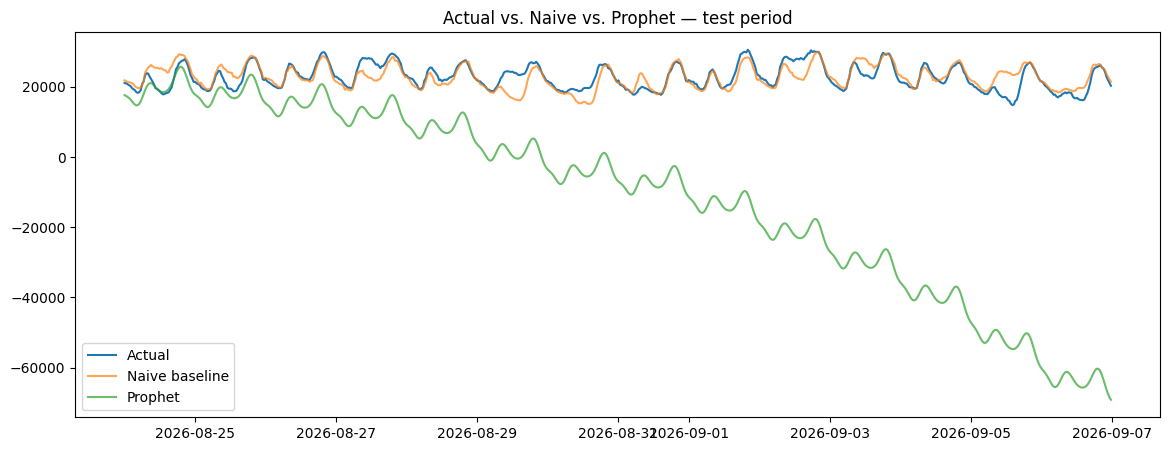

In [26]:
plt.figure(figsize=(14,5))
plt.plot(test["timestamp"], test["ND"], label="Actual")
plt.plot(test["timestamp"], test["naive_pred"], label="Naive baseline", alpha=0.7)
plt.plot(test["timestamp"], test["prophet_pred"], label="Prophet", alpha=0.7)
plt.legend()
plt.title("Actual vs. Naive vs. Prophet — test period")
plt.show()


In [27]:
m2 = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
m2.fit(prophet_train)

forecast2 = m2.predict(future)
test["prophet_pred_v2"] = forecast2["yhat"].values

prophet2_mae = mae(test["ND"], test["prophet_pred_v2"])
prophet2_mape = mape(test["ND"], test["prophet_pred_v2"])
print(f"Prophet v2 (no yearly) — MAE: {prophet2_mae:.0f} MW, MAPE: {prophet2_mape:.2f}%")
print(f"Naive baseline         — MAE: {baseline_mae:.0f} MW, MAPE: {baseline_mape:.2f}%")


Prophet v2 (no yearly) — MAE: 1722 MW, MAPE: 7.81%
Naive baseline         — MAE: 1755 MW, MAPE: 8.08%


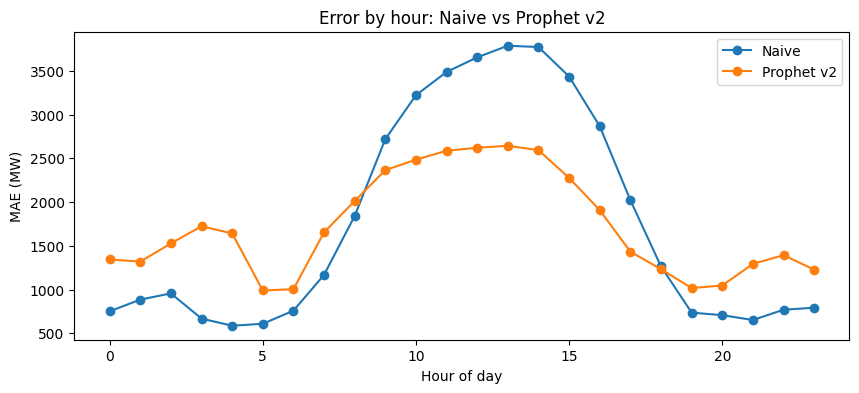

                           EMBEDDED_SOLAR_GENERATION  abs_error_prophet2
EMBEDDED_SOLAR_GENERATION                    1.00000             0.27977
abs_error_prophet2                           0.27977             1.00000


In [28]:
test["abs_error_prophet2"] = np.abs(test["ND"] - test["prophet_pred_v2"])

hourly_error_prophet2 = test.groupby("hour")["abs_error_prophet2"].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_error.index, hourly_error.values, marker="o", label="Naive")
plt.plot(hourly_error_prophet2.index, hourly_error_prophet2.values, marker="o", label="Prophet v2")
plt.xlabel("Hour of day")
plt.ylabel("MAE (MW)")
plt.legend()
plt.title("Error by hour: Naive vs Prophet v2")
plt.show()

print(test[["EMBEDDED_SOLAR_GENERATION", "abs_error_prophet2"]].corr())